In [2]:
# ===================================================
# Fine-Tuning Results Analysis Notebook
# Purpose: Analyze GA fine tuning results
# ===================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [3]:
import os
import json
import pandas as pd


results_dir = r"C:\Users\57305\Documents\FTZ_model_2.0\Experiment_Pipeline\simple_fine_tuning\results\macro\runs"


records = []


for file in os.listdir(results_dir):
    if file.endswith(".json"):
        file_path = os.path.join(results_dir, file)
        with open(file_path, "r", encoding="utf-8") as f:
            data = json.load(f)

        
        h = data.get("hparams", {})
        m = data.get("metrics", {})
        d = data.get("diagnostics", {})
        meta = data.get("meta", {})

        record = {
            "candidate_id": data.get("candidate_id"),
            "seed": data.get("seed"),
            "algo": data.get("algo"),

            
            "best_final": m.get("best_final"),
            "auc_best": m.get("auc_best"),
            "auc_best_norm": m.get("auc_best_norm"),
            "runtime_sec": m.get("runtime_sec"),
            "evals_total": m.get("evals_total"),
            "budget_triggered": m.get("budget_triggered"),

            
            "delta_abs_best": d.get("best", {}).get("delta_abs"),
            "delta_rel_best": d.get("best", {}).get("delta_rel"),

            "sel_mutation": h.get("sel_mutation"),
            "tail_mutation": h.get("tail_mutation"),
            "tourn_size": h.get("tourn_size"),
            "popsize": h.get("popsize"),
            "generations": h.get("generations"),

            
            "L_used": meta.get("L_used"),
            "runtime_sec_meta": meta.get("runtime_sec"),
        }

        records.append(record)


df_finetuning = pd.DataFrame(records)


df_finetuning = df_finetuning.sort_values(by=["candidate_id", "seed"]).reset_index(drop=True)


print(f"✅ {len(df_finetuning)} resultados cargados.")
display(df_finetuning.head())


✅ 1100 resultados cargados.


,candidate_id,seed,algo,best_final,auc_best,auc_best_norm,runtime_sec,evals_total,budget_triggered,delta_abs_best,delta_rel_best,sel_mutation,tail_mutation,tourn_size,popsize,generations,L_used,runtime_sec_meta
0,57,101,macro,438.65,43847.750,438.47750,141.766294,2122,False,1.50,0.003431,0.005,0.225,5.0,22,100,33,141.766294
1,57,202,macro,438.65,43858.475,438.58475,144.620490,2122,False,1.95,0.004465,0.005,0.225,5.0,22,100,33,144.620490
2,57,303,macro,438.65,43830.125,438.30125,142.635465,2122,False,1.95,0.004465,0.005,0.225,5.0,22,100,33,142.635465
3,57,404,macro,438.65,43856.975,438.56975,144.416737,2122,False,1.65,0.003776,0.005,0.225,5.0,22,100,33,144.416737
4,57,505,macro,438.65,43845.350,438.45350,145.778395,2122,False,1.50,0.003431,0.005,0.225,5.0,22,100,33,145.778395


In [4]:
import pandas as pd
import numpy as np
from scipy.stats import rankdata, kruskal

# Métrica base
metric = "auc_best_norm"


groups = [g[metric].values for _, g in df_finetuning.groupby("candidate_id")]
kruskal_result = kruskal(*groups)

print(f"Kruskal–Wallis H = {kruskal_result.statistic:.3f}, p = {kruskal_result.pvalue:.3e}")


Kruskal–Wallis H = 618.529, p = 4.028e-76


In [5]:
# Añade los ranks globales (rangos de menor a mayor)
df_finetuning["rank"] = rankdata(df_finetuning[metric])

# Promedio de rangos por candidato
rank_means = (
    df_finetuning.groupby("candidate_id")["rank"]
    .agg(["mean", "std", "count"])
    .sort_values("mean", ascending=False)
)

rank_means["rank_mean_diff"] = rank_means["mean"] - rank_means["mean"].mean()
display(rank_means.head(10))


,mean,std,count,rank_mean_diff
candidate_id,,,,
159,954.954545,159.819188,11,404.454545
597,952.818182,114.550485,11,402.318182
1044,948.636364,109.478557,11,398.136364
99,944.681818,151.199913,11,394.181818
600,921.045455,74.570254,11,370.545455
228,912.954545,171.373781,11,362.454545
1232,883.863636,145.203149,11,333.363636
735,867.545455,179.292980,11,317.045455
969,867.318182,200.101508,11,316.818182


C:\Users\57305\AppData\Local\Temp\ipykernel_36076\759400793.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


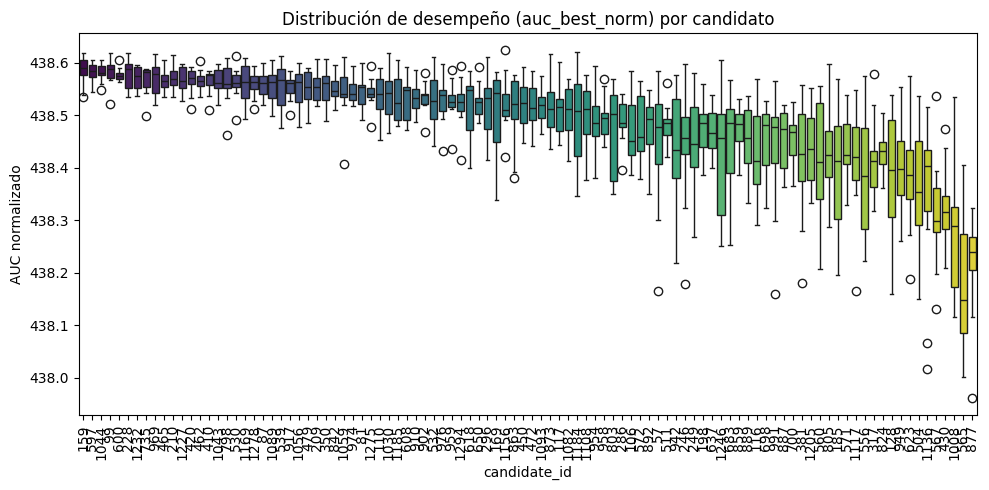

In [6]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_finetuning,
    x="candidate_id",
    y="auc_best_norm",
    order=rank_means.index,  # ordenados por rango promedio
    palette="viridis"
)
plt.xticks(rotation=90)
plt.title("Distribución de desempeño (auc_best_norm) por candidato")
plt.ylabel("AUC normalizado")
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from scipy.stats import mannwhitneyu
import itertools

# --- Filtramos la métrica de interés ---
metric = "auc_best_norm"

# Agrupamos por candidato
groups = {cid: g[metric].values for cid, g in df_finetuning.groupby("candidate_id")}

# Generamos todas las combinaciones de pares (sin repetición)
pairs = list(itertools.combinations(groups.keys(), 2))

# Ejecutamos Mann-Whitney U para cada par (una-sided: "greater" → c1 > c2)
results = []
for c1, c2 in pairs:
    stat, p = mannwhitneyu(groups[c1], groups[c2], alternative="greater")
    results.append({
        "comparison": f"{c1} > {c2}",
        "n_c1": len(groups[c1]),
        "n_c2": len(groups[c2]),
        "statistic": stat,
        "p_value": p
    })

df_wilcoxon = pd.DataFrame(results).sort_values("p_value").reset_index(drop=True)

# Aplicamos Bonferroni para corregir comparaciones múltiples
df_wilcoxon["p_adj_bonferroni"] = df_wilcoxon["p_value"] * len(df_wilcoxon)
df_wilcoxon["significant"] = df_wilcoxon["p_adj_bonferroni"] < 0.05

display(df_wilcoxon.head(10))


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,462 > 1136,11,11,121.0,0.00004,0.198959,False
1,462 > 887,11,11,121.0,0.00004,0.198959,False
2,1044 > 1136,11,11,121.0,0.00004,0.199886,False
3,465 > 887,11,11,121.0,0.00004,0.199886,False
4,462 > 1008,11,11,121.0,0.00004,0.199886,False
5,462 > 877,11,11,121.0,0.00004,0.199886,False
6,462 > 859,11,11,121.0,0.00004,0.199886,False
7,228 > 887,11,11,121.0,0.00004,0.199886,False
8,462 > 698,11,11,121.0,0.00004,0.199886,False
9,462 > 700,11,11,121.0,0.00004,0.199886,False


In [8]:
df_wilcoxon[df_wilcoxon["significant"]]


,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant


In [9]:
df_wilcoxon.sort_values("p_value", ascending=True)
df_wilcoxon.sort_values("statistic", ascending=False)

,comparison,n_c1,n_c2,statistic,p_value,p_adj_bonferroni,significant
0,462 > 1136,11,11,121.0,0.000040,0.198959,False
1,462 > 887,11,11,121.0,0.000040,0.198959,False
2,1044 > 1136,11,11,121.0,0.000040,0.199886,False
3,465 > 887,11,11,121.0,0.000040,0.199886,False
4,462 > 1008,11,11,121.0,0.000040,0.199886,False
...,...,...,...,...,...,...,...
4945,430 > 735,11,11,0.0,0.999969,4949.848334,False
4946,286 > 1044,11,11,0.0,0.999969,4949.848334,False
4947,887 > 1044,11,11,0.0,0.999969,4949.848334,False
4948,877 > 902,11,11,0.0,0.999970,4949.849783,False


In [10]:
import pandas as pd
import numpy as np
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import itertools

# --- Parámetros ---
metric = "auc_best_norm"
alpha = 0.05

# --- Construir matriz seed × candidate ---
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

# --- Generar combinaciones de pares ---
candidates = pivot.columns.tolist()
pairs = list(itertools.combinations(candidates, 2))

results = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()  # elimina seeds faltantes
    if len(data) < 5:
        continue  # descarta pares con pocas observaciones

    # Diferencias por seed
    diff = data[c1] - data[c2]

    # Test una-cola: H1 = c1 > c2
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")

    results.append({
        "c1": c1,
        "c2": c2,
        "comparison": f"{c1} > {c2}",
        "n_seeds": len(data),
        "statistic": stat,
        "p_value": p
    })

df_tests = pd.DataFrame(results)

# --- Corrección Holm (recomendada) ---
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=alpha, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# --- Corrección Bonferroni (opcional) ---
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < alpha

# --- Ordenar por evidencia más fuerte ---
df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)

display(df_tests.head(15))


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,57,81,57 > 81,11,8.0,0.990723,1.0,False,1.0,False
1,57,87,57 > 87,11,4.0,0.997559,1.0,False,1.0,False
2,57,99,57 > 99,11,0.0,1.000000,1.0,False,1.0,False
3,57,106,57 > 106,11,27.0,0.711426,1.0,False,1.0,False
4,57,110,57 > 110,11,10.0,0.983887,1.0,False,1.0,False
5,57,116,57 > 116,11,40.0,0.288574,1.0,False,1.0,False
6,57,117,57 > 117,11,16.0,0.938477,1.0,False,1.0,False
7,57,128,57 > 128,11,42.0,0.232422,1.0,False,1.0,False
8,57,159,57 > 159,11,0.0,1.000000,1.0,False,1.0,False
9,57,169,57 > 169,11,20.0,0.879883,1.0,False,1.0,False


In [11]:
df_tests[df_tests["significant_holm"]]


,c1,c2,comparison,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf


In [12]:
# df_tests debe provenir del bloque anterior (Wilcoxon pareado)
# Columnas requeridas: c1, c2, significant_holm

# Inicializamos contadores
candidates = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=candidates, columns=["wins", "losses"], data=0)

for _, row in df_tests.iterrows():
    c1, c2 = row["c1"], row["c2"]
    if row["significant_holm"]:  # c1 > c2 con significancia
        summary.loc[c1, "wins"] += 1
        summary.loc[c2, "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary = summary.sort_values("net_wins", ascending=False)

display(summary)


,wins,losses,net_wins
57,0,0,0
81,0,0,0
87,0,0,0
99,0,0,0
106,0,0,0
...,...,...,...
1232,0,0,0
1246,0,0,0
1275,0,0,0
1278,0,0,0


# Candidatos

In [13]:
import numpy as np
import pandas as pd

# Cálculo del LCB95
g = df_finetuning.groupby("candidate_id")["auc_best_norm"]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# n=11 → df=10 → t_{0.95,10} ≈ 1.812 (unilateral 95%)
tcrit = 1.812
lcb95 = mean - tcrit * se

# Tabla ordenada únicamente por desempeño robusto
df_lcb = (
    pd.DataFrame({"auc_mean": mean, "auc_std": std, "lcb95": lcb95})
    .sort_values("lcb95", ascending=False)
)

# Elige top K para test pareado
top = 10
short_candidates = df_lcb.head(top).index.tolist()

df_lcb.head(10), short_candidates


(                auc_mean   auc_std       lcb95
 candidate_id                                  
 597           438.582295  0.018150  438.572380
 1044          438.581341  0.017120  438.571987
 600           438.576977  0.011803  438.570529
 159           438.584886  0.027587  438.569815
 99            438.581750  0.025012  438.568085
 228           438.577386  0.028620  438.561750
 1232          438.570977  0.021918  438.559003
 462           438.566614  0.017984  438.556788
 465           438.568250  0.022170  438.556138
 210           438.568386  0.023766  438.555402,
 [597, 1044, 600, 159, 99, 228, 1232, 462, 465, 210])

In [14]:
import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

metric = "auc_best_norm"
pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

pairs = list(itertools.combinations(short_candidates, 2))
rows = []
for c1, c2 in pairs:
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5:
        continue
    diff = data[c1] - data[c2]  # pareado por seed
    stat, p = wilcoxon(diff, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(data), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

# Corrección Holm dentro del shortlist (mucho menos comparaciones)
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

# Bonferroni opcional (clip 1.0)
p_bonf = np.minimum(df_tests["p_value"] * len(df_tests), 1.0)
df_tests["p_bonf"] = p_bonf
df_tests["significant_bonf"] = df_tests["p_bonf"] < 0.05

df_tests = df_tests.sort_values("p_holm").reset_index(drop=True)
df_tests.head(20)


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm,p_bonf,significant_bonf
0,1044,1232,11,60.0,0.005859,0.263672,False,0.263672,False
1,597,462,11,57.5,0.013184,0.580078,False,0.593262,False
2,597,1232,11,57.0,0.016113,0.692871,False,0.725098,False
3,597,210,11,55.0,0.026367,1.000000,False,1.000000,False
4,159,1232,11,55.0,0.026855,1.000000,False,1.000000,False
5,99,462,11,55.0,0.026855,1.000000,False,1.000000,False
6,597,465,11,54.5,0.028320,1.000000,False,1.000000,False
7,159,465,11,53.0,0.041504,1.000000,False,1.000000,False
8,1044,465,11,52.5,0.043457,1.000000,False,1.000000,False
9,99,465,11,51.5,0.050781,1.000000,False,1.000000,False


In [15]:
# Resumen de victorias/derrotas usando Holm
cands = sorted(set(df_tests["c1"]).union(df_tests["c2"]))
summary = pd.DataFrame(index=cands, columns=["wins","losses"], data=0)

for _, row in df_tests.iterrows():
    if row["significant_holm"]:
        summary.loc[row["c1"], "wins"]  += 1
        summary.loc[row["c2"], "losses"] += 1

summary["net_wins"] = summary["wins"] - summary["losses"]
summary["win_rate"] = summary["wins"] / (summary["wins"] + summary["losses"] + 1e-9)
summary = summary.sort_values(["win_rate","net_wins","wins"], ascending=[False, False, False])

summary


,wins,losses,net_wins,win_rate
99,0,0,0,0.0
159,0,0,0,0.0
210,0,0,0,0.0
228,0,0,0,0.0
462,0,0,0,0.0
465,0,0,0,0.0
597,0,0,0,0.0
600,0,0,0,0.0
1044,0,0,0,0.0
1232,0,0,0,0.0


In [16]:
import numpy as np
import pandas as pd
from scipy.stats import t

metric = "auc_best_norm"
top = 10  # tamaño del shortlist

g = df_finetuning.groupby("candidate_id")[metric]
mean = g.mean()
std  = g.std(ddof=1)
n    = g.count()
se   = std / np.sqrt(n)

# t crítico unil. 95% por candidato (por si algún n != 11)
tcrit = t.ppf(1 - 0.05, df=(n - 1).clip(lower=1))
lcb95 = mean - tcrit * se
p10   = g.quantile(0.10)

df_lcb = (pd.DataFrame({
    "auc_mean": mean, "auc_std": std, "n": n, "se": se, "lcb95": lcb95, "p10": p10
}).sort_values(["lcb95","p10","auc_mean"], ascending=[False, False, False]))

short_candidates = df_lcb.head(top).index.tolist()
display(df_lcb.head(top))
print("Shortlist:", short_candidates)


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
597,438.582295,0.018150,11,0.005472,438.572377,438.56375
1044,438.581341,0.017120,11,0.005162,438.571985,438.55925
600,438.576977,0.011803,11,0.003559,438.570527,438.56825
159,438.584886,0.027587,11,0.008318,438.569811,438.53825
99,438.581750,0.025012,11,0.007541,438.568081,438.56675
228,438.577386,0.028620,11,0.008629,438.561746,438.54125
1232,438.570977,0.021918,11,0.006609,438.558999,438.54575
462,438.566614,0.017984,11,0.005422,438.556786,438.55625
465,438.568250,0.022170,11,0.006685,438.556135,438.54575


Shortlist: [597, 1044, 600, 159, 99, 228, 1232, 462, 465, 210]


In [17]:
import itertools
from scipy.stats import wilcoxon

pivot = df_finetuning.pivot_table(index="seed", columns="candidate_id", values=metric)

rows = []
for c1, c2 in itertools.combinations(short_candidates, 2):
    data = pivot[[c1, c2]].dropna()
    if len(data) < 5: 
        continue
    d = data[c1] - data[c2]
    stat, p = wilcoxon(d, alternative="greater", zero_method="pratt")
    rows.append({"c1": c1, "c2": c2, "n_seeds": len(d), "statistic": stat, "p_value": p})

df_tests = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)

from statsmodels.stats.multitest import multipletests
rej_holm, p_holm, _, _ = multipletests(df_tests["p_value"], alpha=0.05, method="holm")
df_tests["p_holm"] = p_holm
df_tests["significant_holm"] = rej_holm

display(df_tests.head(20))

# Tamaño de efecto (Cliff’s delta)
def cliffs_delta(x, y):
    x = np.asarray(x); y = np.asarray(y)
    gt = sum((xi > yi) for xi in x for yi in y)
    lt = sum((xi < yi) for xi in x for yi in y)
    return (gt - lt) / (len(x) * len(y))

effects = []
for _, r in df_tests.iterrows():
    x = df_finetuning.loc[df_finetuning["candidate_id"]==r["c1"], metric].values
    y = df_finetuning.loc[df_finetuning["candidate_id"]==r["c2"], metric].values
    effects.append({"c1": r["c1"], "c2": r["c2"], "cliffs_delta": cliffs_delta(x, y)})

df_effects = pd.DataFrame(effects).sort_values("cliffs_delta", ascending=False)
display(df_effects.head(20))


,c1,c2,n_seeds,statistic,p_value,p_holm,significant_holm
0,1044,1232,11,60.0,0.005859,0.263672,False
1,597,462,11,57.5,0.013184,0.580078,False
2,597,1232,11,57.0,0.016113,0.692871,False
3,597,210,11,55.0,0.026367,1.000000,False
4,159,1232,11,55.0,0.026855,1.000000,False
5,99,462,11,55.0,0.026855,1.000000,False
6,597,465,11,54.5,0.028320,1.000000,False
7,159,465,11,53.0,0.041504,1.000000,False
8,1044,465,11,52.5,0.043457,1.000000,False
9,99,465,11,51.5,0.050781,1.000000,False


,c1,c2,cliffs_delta
1,597,462,0.520661
5,99,462,0.520661
16,159,462,0.512397
18,600,462,0.471074
10,1044,462,0.471074
7,159,465,0.454545
11,159,210,0.438017
13,99,210,0.413223
9,99,465,0.396694
3,597,210,0.396694


In [18]:
from scipy.stats import wilcoxon

def noninferiority_paired(d, Delta):
    # H0: mu_d <= -Delta  vs  H1: mu_d > -Delta
    # Testea d + Delta > 0 (una cola)
    stat, p = wilcoxon(d + Delta, alternative="greater", zero_method="pratt")
    return p

def nosuperiority_paired(d, Delta):
    # H0: mu_d >=  Delta  vs  H1: mu_d <  Delta
    # Testea -(d - Delta) > 0  => Delta - d > 0  (una cola)
    stat, p = wilcoxon(Delta - d, alternative="greater", zero_method="pratt")
    return p

Delta = 0.010  # margen práctico; ajusta a tu unidad

champion = short_candidates[0]  # top por LCB95
pivot_short = pivot[short_candidates].dropna()
tost_rows = []
for c in short_candidates[1:]:
    d = (pivot_short[champion] - pivot_short[c]).dropna()
    if len(d) < 5:
        continue
    p_noninf = noninferiority_paired(d, Delta)
    p_nosup = nosuperiority_paired(d, Delta)
    # Equivalencia si ambas p < alpha
    tost_rows.append({"champion": champion, "challenger": c,
                      "n_seeds": len(d),
                      "p_noninferior": p_noninf, "p_nosuperior": p_nosup,
                      "equivalent_(TOST)": (p_noninf < 0.05) and (p_nosup < 0.05)})

df_tost = pd.DataFrame(tost_rows).sort_values(["equivalent_(TOST)","p_noninferior","p_nosuperior"],
                                              ascending=[False, True, True])
display(df_tost)


,champion,challenger,n_seeds,p_noninferior,p_nosuperior,equivalent_(TOST)
5,597,1232,11,0.000977,0.711426,False
6,597,462,11,0.001465,0.817383,False
7,597,465,11,0.004883,0.711426,False
8,597,210,11,0.006348,0.732910,False
1,597,600,11,0.011719,0.226074,False
0,597,1044,11,0.050781,0.103027,False
4,597,228,11,0.087402,0.288574,False
3,597,99,11,0.114746,0.114746,False
2,597,159,11,0.182617,0.087402,False


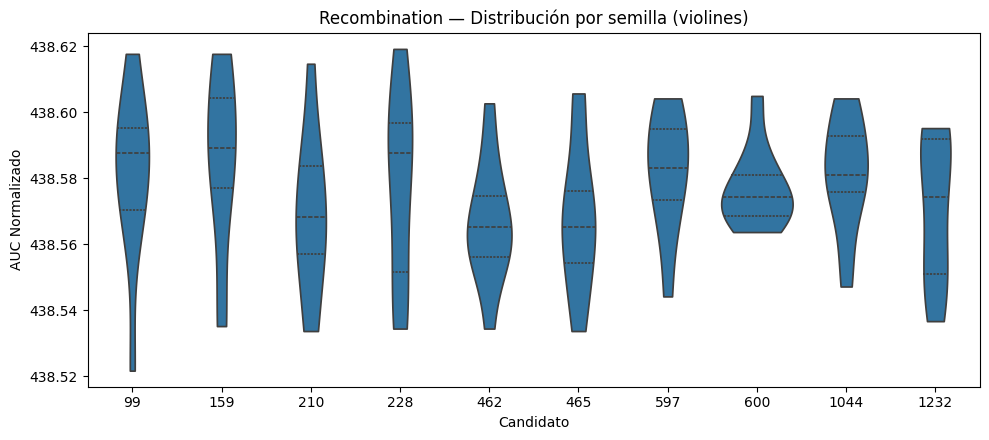

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

top10 = [597, 1044, 600, 159, 99, 228, 1232, 462, 465, 210]
subset = df_finetuning[df_finetuning["candidate_id"].isin(top10)]

plt.figure(figsize=(10,4.5))
sns.violinplot(data=subset, x="candidate_id", y="auc_best_norm",
               inner="quartile", cut=0)
plt.title("Macro — Distribución por semilla (violines)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.tight_layout()
plt.show()

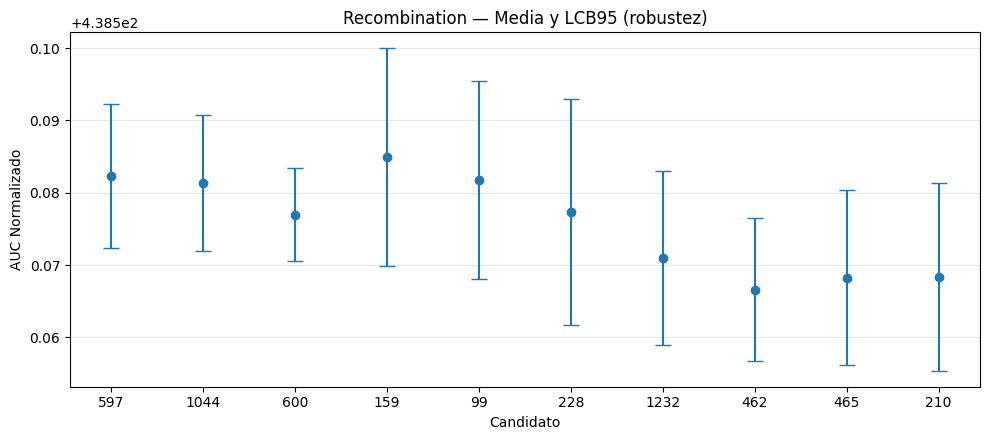

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

df_plot = df_lcb.loc[top10, ["auc_mean","lcb95"]].copy()
df_plot["yerr_down"] = df_plot["auc_mean"] - df_plot["lcb95"]

plt.figure(figsize=(10,4.5))
plt.errorbar(df_plot.index.astype(str),
             df_plot["auc_mean"],
             yerr=df_plot["yerr_down"],
             fmt='o', capsize=6)
plt.title("Macro — Media y LCB95 (robustez)")
plt.xlabel("Candidato")
plt.ylabel("AUC Normalizado")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

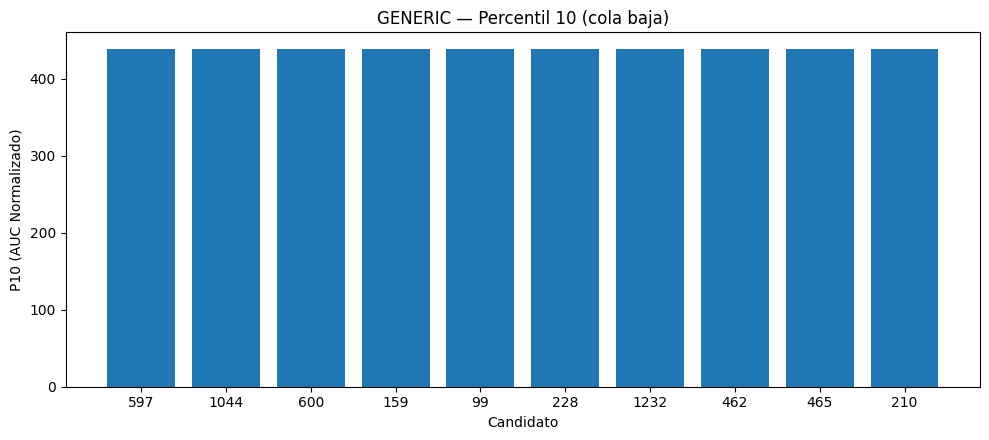

In [ ]:
import matplotlib.pyplot as plt

p10_plot = df_lcb.loc[top10, "p10"]

plt.figure(figsize=(10,4.5))
plt.bar(p10_plot.index.astype(str), p10_plot.values)
plt.title("Macro — Percentil 10 (cola baja)")
plt.xlabel("Candidato")
plt.ylabel("P10 (AUC Normalizado)")
plt.tight_layout()
plt.show()


In [27]:
winner = 597
report = (
    df_lcb.loc[top10, ["auc_mean","auc_std","n","se","lcb95","p10"]]
      .sort_values("lcb95", ascending=False)
)
print("WINNER (robustez):", winner)
display(report)

WINNER (robustez): 597


,auc_mean,auc_std,n,se,lcb95,p10
candidate_id,,,,,,
597,438.582295,0.018150,11,0.005472,438.572377,438.56375
1044,438.581341,0.017120,11,0.005162,438.571985,438.55925
600,438.576977,0.011803,11,0.003559,438.570527,438.56825
159,438.584886,0.027587,11,0.008318,438.569811,438.53825
99,438.581750,0.025012,11,0.007541,438.568081,438.56675
228,438.577386,0.028620,11,0.008629,438.561746,438.54125
1232,438.570977,0.021918,11,0.006609,438.558999,438.54575
462,438.566614,0.017984,11,0.005422,438.556786,438.55625
465,438.568250,0.022170,11,0.006685,438.556135,438.54575


In [28]:
cid = 597

params_597 = (
    df_finetuning
    .loc[df_finetuning["candidate_id"] == cid, ["sel_mutation", "tail_mutation", "tourn_size"]]
    .iloc[0]
)

params_597

sel_mutation     0.05
tail_mutation    0.05
tourn_size       5.00
Name: 462, dtype: float64